In [1]:
!pip install transformers==4.41.1
!pip install bio
!pip install obonet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 70.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 1.0.0rc2
    Uninstalling huggingface-hub-1.0.0rc2:
      Successfully uninstalled huggingface-hub-1.0.0rc2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.53.3
    Uninstalling transformers-4.53.3:
      Successfully uninstalled transformers-4.53.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of

In [2]:
import math
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torch import nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics.classification import MultilabelF1Score

class Config:
    MAIN_DIR = "/kaggle/input/cafa-6-protein-function-prediction"
    train_sequences_path = MAIN_DIR + "/Train/train_sequences.fasta"
    train_labels_path = MAIN_DIR + "/Train/train_terms.tsv"
    test_sequences_path = MAIN_DIR + "/Test (Targets)/testsuperset.fasta"
    
    num_labels = 500
    n_epochs = 10
    batch_size = 64
    lr = 0.001
    weight_decay = 1e-4
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    seed = 42

config = Config()

torch.manual_seed(config.seed)
np.random.seed(config.seed)

EMBEDS_MAP = {
    "T5": "t5embeds",
    "ProtBERT": "cafa6-protbert-embeddings",
    "ESM2": "cafa-6-ems-embedding-dataset"
}

EMBEDS_DIM = {
    "T5": 1024,
    "ProtBERT": 1024,
    "ESM2": 1280
}

In [3]:
class ProteinSequenceDataset(Dataset):    
    def __init__(self, datatype, embeddings_source):
        super().__init__()
        self.datatype = datatype
        self.embeddings_source = embeddings_source
        
        if embeddings_source in ["ProtBERT", "ESM2"]:
            embeds = np.load(f"/kaggle/input/{EMBEDS_MAP[embeddings_source]}/{datatype}_embeddings.npy")
            ids = np.load(f"/kaggle/input/{EMBEDS_MAP[embeddings_source]}/{datatype}_ids.npy")
        elif embeddings_source == "T5":
            embeds = np.load(f"/kaggle/input/{EMBEDS_MAP[embeddings_source]}/{datatype}_embeds.npy")
            ids = np.load(f"/kaggle/input/{EMBEDS_MAP[embeddings_source]}/{datatype}_ids.npy")
        
        self.df = pd.DataFrame({
            "EntryID": ids,
            "embed": [embeds[i] for i in range(embeds.shape[0])]
        })
        
        if datatype == "train":
            np_labels = np.load(f"/kaggle/input/cafa6top500/train_targets_top{config.num_labels}.npy")
            df_labels = pd.DataFrame({
                'EntryID': self.df['EntryID'],
                'labels_vect': [row for row in np_labels]
            })
            self.df = self.df.merge(df_labels, on="EntryID")
            
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        embed = torch.tensor(self.df.iloc[index]["embed"], dtype=torch.float32)
        
        if self.datatype == "train":
            targets = torch.tensor(self.df.iloc[index]["labels_vect"], dtype=torch.float32)
            return embed, targets
        else:
            protein_id = self.df.iloc[index]["EntryID"]
            return embed, protein_id

In [4]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        
        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout)
        )
        
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        attn_out, _ = self.attention(x, x, x)
        x = self.norm1(x + self.dropout(attn_out))
        
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        
        return x


class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for transformer."""
    def __init__(self, embed_dim, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class ImprovedTransformerMLP(nn.Module):
    """Enhanced MLP with multiple transformer encoder blocks."""
    def __init__(self, input_dim, num_classes, 
                 hidden_dims=[1024, 512], 
                 num_transformer_layers=3,
                 num_heads=8,
                 ff_expansion=4,
                 dropout=0.3):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.BatchNorm1d(hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.pos_encoding = PositionalEncoding(
            embed_dim=hidden_dims[1],
            dropout=0.1
        )
        
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=hidden_dims[1],
                num_heads=num_heads,
                ff_dim=hidden_dims[1] * ff_expansion,
                dropout=0.1
            )
            for _ in range(num_transformer_layers)
        ])
        
        self.final_norm = nn.LayerNorm(hidden_dims[1])
        
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dims[1], 768),
            nn.BatchNorm1d(768),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(768, 384),
            nn.BatchNorm1d(384),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(384, num_classes)
        )
        
        self._init_weights()
        
    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.BatchNorm1d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
        
    def forward(self, x):
        encoded = self.encoder(x)
        x_seq = encoded.unsqueeze(1)
        x_seq = self.pos_encoding(x_seq)
        
        for transformer_block in self.transformer_blocks:
            x_seq = transformer_block(x_seq)
        x_seq = self.final_norm(x_seq)
        
        encoded = x_seq.squeeze(1)
        output = self.decoder(encoded)
        
        return output

In [5]:
def train_model(embeddings_source, train_size=0.9):    
    print(f"\n{'='*60}")
    print(f"Training with {embeddings_source} embeddings")
    print(f"{'='*60}\n")
    
    train_dataset = ProteinSequenceDataset(datatype="train", embeddings_source=embeddings_source)
    
    train_len = int(len(train_dataset) * train_size)
    val_len = len(train_dataset) - train_len
    train_set, val_set = random_split(
        train_dataset,
        [train_len, val_len],
        generator=torch.Generator().manual_seed(config.seed)
    )
    
    train_loader = DataLoader(
        train_set,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_set,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    
    model = nn.DataParallel(
        ImprovedTransformerMLP(
            input_dim=EMBEDS_DIM[embeddings_source],
            num_classes=config.num_labels,
            hidden_dims=[1024, 512],
            num_transformer_layers=3,
            num_heads=8,
            ff_expansion=4,
            dropout=0.3
        )
    ).to(config.device)
    print(EMBEDS_DIM[embeddings_source], config.num_labels)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.lr,
        weight_decay=config.weight_decay
    )
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=2,
        verbose=True
    )
    
    f1_metric = MultilabelF1Score(num_labels=config.num_labels, average='macro').to(config.device)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_f1': [],
        'val_f1': []
    }
    
    best_val_f1 = 0.0
    best_model_state = None
    patience_counter = 0
    early_stopping_patience = 5
    
    print("Starting training...")
    for epoch in range(config.n_epochs):
        print(f"\nEpoch {epoch+1}/{config.n_epochs}")
        print("-" * 40)
        
        model.train()
        train_losses, train_f1s = [], []
        
        for embed, targets in tqdm(train_loader, desc="Training"):
            embed = embed.to(config.device, non_blocking=True)
            targets = targets.to(config.device, non_blocking=True)
            
            optimizer.zero_grad()
            outputs = model(embed)
            loss = criterion(outputs, targets)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_losses.append(loss.item())
            
            with torch.no_grad():
                preds = torch.sigmoid(outputs)
                f1 = f1_metric(preds, targets.int())
                train_f1s.append(f1.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_train_f1 = np.mean(train_f1s)
        
        model.eval()
        val_losses, val_f1s = [], []
        
        with torch.no_grad():
            for embed, targets in tqdm(val_loader, desc="Validation"):
                embed = embed.to(config.device, non_blocking=True)
                targets = targets.to(config.device, non_blocking=True)
                
                outputs = model(embed)
                loss = criterion(outputs, targets)
                
                preds = torch.sigmoid(outputs)
                f1 = f1_metric(preds, targets.int())
                
                val_losses.append(loss.item())
                val_f1s.append(f1.item())
        
        avg_val_loss = np.mean(val_losses)
        avg_val_f1 = np.mean(val_f1s)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_f1'].append(avg_train_f1)
        history['val_f1'].append(avg_val_f1)
        
        print(f"Train Loss: {avg_train_loss} | Train F1: {avg_train_f1}")
        print(f"Val Loss:   {avg_val_loss} | Val F1:   {avg_val_f1}")
        
        if avg_val_f1 > best_val_f1:
            best_val_f1 = avg_val_f1
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"✓ New best model! (Val F1: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            print(f"No improvement ({patience_counter}/{early_stopping_patience})")
        
        scheduler.step(avg_val_f1)
        
        if patience_counter >= early_stopping_patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n{'='*60}")
        print(f"Training complete! Best Val F1: {best_val_f1:.4f}")
        print(f"{'='*60}\n")
    
    return model, history

protbert_model, history = train_model(embeddings_source="ESM2")


Training with ESM2 embeddings



/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


1280 500
Starting training...

Epoch 1/10
----------------------------------------


Training:   0%|          | 0/1159 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return F.linear(input, self.weight, self.bias)
Validation: 100%|██████████| 129/129 [00:02<00:00, 63.60it/s]


Train Loss: 0.040484326916511354 | Train F1: 0.0005144981381986001
Val Loss:   0.03480144148302633 | Val F1:   0.0
No improvement (1/5)

Epoch 2/10
----------------------------------------


...

Train Loss: 0.03223656163718857 | Train F1: 5.109147966226259e-05
Val Loss:   0.03201574105913787 | Val F1:   0.0
No improvement (3/5)

Epoch 4/10
----------------------------------------


Validation: 100%|██████████| 129/129 [00:02<00:00, 64.00it/s]


Train Loss: 0.032112049671714424 | Train F1: 3.307658339983392e-05
Val Loss:   0.03171593427311543 | Val F1:   0.0
No improvement (4/5)

Epoch 5/10
----------------------------------------


Validation: 100%|██████████| 129/129 [00:02<00:00, 63.85it/s]


Train Loss: 0.03186355863566847 | Train F1: 7.545404749947766e-06
Val Loss:   0.0315050903216813 | Val F1:   0.0
No improvement (5/5)

Early stopping triggered after 5 epochs


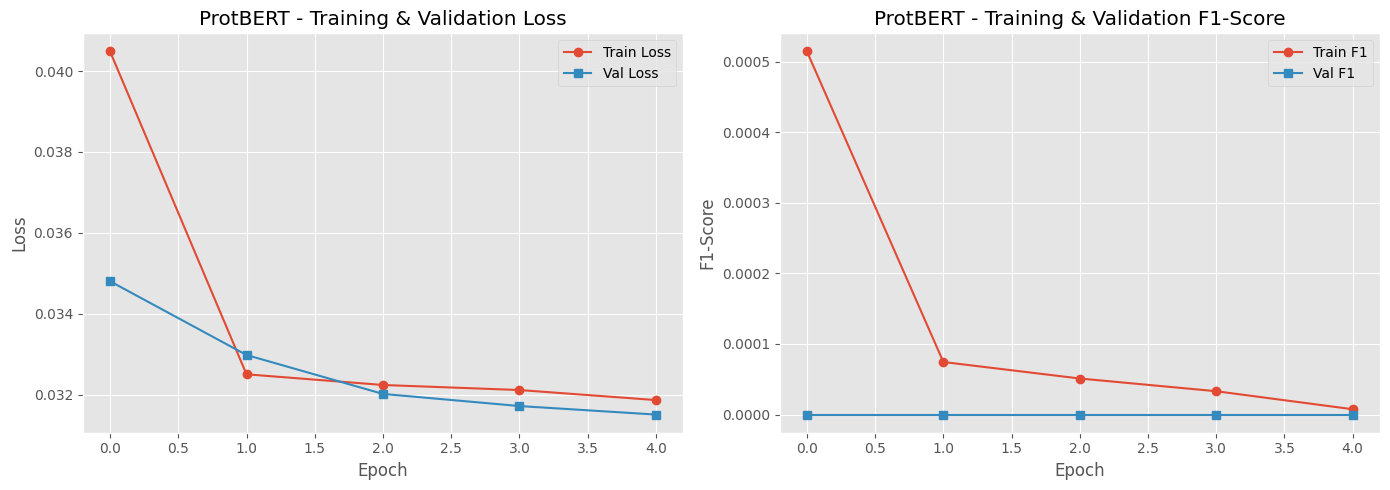

In [6]:
def plot_training_history(history, embeddings_source):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['val_loss'], label='Val Loss', marker='s')
    ax1.set_title(f'{embeddings_source} - Training & Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(history['train_f1'], label='Train F1', marker='o')
    ax2.plot(history['val_f1'], label='Val F1', marker='s')
    ax2.set_title(f'{embeddings_source} - Training & Validation F1-Score')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1-Score')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
plot_training_history(history, "ProtBERT")

In [7]:
def generate_predictions(model, embeddings_source, threshold=0.01):    
    print("\nGenerating predictions on test set...")
    
    test_dataset = ProteinSequenceDataset(datatype="test", embeddings_source=embeddings_source)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    labels_df = pd.read_csv(config.train_labels_path, sep="\t", header=None)
    labels_df.columns = ["EntryID", "term", "ontology"]
    
    top_terms = labels_df.groupby("term")["EntryID"].count().sort_values(ascending=False)
    go_terms = top_terms[:config.num_labels].index.values
    
    model.eval()
    
    all_ids = []
    all_terms = []
    all_confs = []
    
    with torch.no_grad():
        for embed, protein_id in tqdm(test_loader, desc="Predicting"):
            embed = embed.to(config.device)
            outputs = model(embed)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            
            for term, conf in zip(go_terms, probs):
                if conf > threshold:
                    all_ids.append(protein_id[0])
                    all_terms.append(term)
                    all_confs.append(round(conf, 3))
    
    submission_df = pd.DataFrame({
        "Id": all_ids,
        "GO_term": all_terms,
        "Confidence": all_confs
    })
    
    print(f"Generated {len(submission_df)} predictions")
    print(f"Unique proteins: {submission_df['Id'].nunique()}")
    print(f"Unique GO terms: {submission_df['GO_term'].nunique()}")
    
    return submission_df

submission_df = generate_predictions(protbert_model, "ESM2", threshold=0.01)
    
submission_df.to_csv('submission.tsv', sep='\t', header=False, index=False)
print("\nSubmission file saved as 'submission.tsv'")
print(f"Total predictions: {len(submission_df)}")


Generating predictions on test set...


Predicting: 100%|██████████| 224309/224309 [22:36<00:00, 165.39it/s]


Generated 6729270 predictions
Unique proteins: 224309
Unique GO terms: 30

Submission file saved as 'submission.tsv'
Total predictions: 6729270
